In [1]:
# ============================================================
# BLOCK 1 — INSTALLATION AND IMPORTS
# ============================================================

!pip install -q tsplib95 elkai

from __future__ import annotations

import os
import random
import time
from dataclasses import dataclass
from typing import Optional
from collections import Counter, defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt
import tsplib95

try:
    import elkai
    HAS_ELKAI = True
except Exception:
    HAS_ELKAI = False

print("Environment ready.")
print("ELKAI available:", HAS_ELKAI)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
bigframes 2.42.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.
spopt 0.7.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
momepy 0.11.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
Environment ready.
ELKAI available: True


In [2]:
# ============================================================
# BLOCK 2 — CONFIGURATION
# ============================================================

TSPLIB_BEST_KNOWN = {
    "a280": 2579,
    "ali535": 202339,
    "att48": 10628,
    "att532": 27686,
    "bayg29": 1610,
    "bays29": 2020,
    "berlin52": 7542,
    "bier127": 118282,
    "brazil58": 25395,
    "brd14051": 469385,
    "brg180": 1950,
    "burma14": 3323,
    "ch130": 6110,
    "ch150": 6528,
    "d198": 15780,
    "d493": 35002,
    "d657": 48912,
    "d1291": 50801,
    "d1655": 62128,
    "d2103": 80450,
    "d15112": 1573084,
    "d18512": 645238,
    "dantzig42": 699,
    "dsj1000": 18660188,
    "eil51": 426,
    "eil76": 538,
    "eil101": 629,
    "fl417": 11861,
    "fl1400": 20127,
    "fl1577": 22249,
    "fl3795": 28772,
    "fnl4461": 182566,
    "fri26": 937,
    "gil262": 2378,
    "gr17": 2085,
    "gr21": 2707,
    "gr24": 1272,
    "gr48": 5046,
    "gr96": 55209,
    "gr120": 6942,
    "gr137": 69853,
    "gr202": 40160,
    "gr229": 134602,
    "gr431": 171414,
    "gr666": 294358,
    "hk48": 11461,
    "kroa100": 21282,
    "krob100": 22141,
    "kroc100": 20749,
    "krod100": 21294,
    "kroe100": 22068,
    "kroa150": 26524,
    "krob150": 26130,
    "kroa200": 29368,
    "krob200": 29437,
    "lin105": 14379,
    "lin318": 42029,
    "linhp318": 41345,
    "nrw1379": 56638,
    "p654": 34643,
    "pa561": 2763,
    "pcb442": 50778,
    "pcb1173": 56892,
    "pcb3038": 137694,
    "pr76": 108159,
    "pr107": 44303,
    "pr124": 59030,
    "pr136": 96772,
    "pr144": 58537,
    "pr152": 73682,
    "pr226": 80369,
    "pr264": 49135,
    "pr299": 48191,
    "pr439": 107217,
    "pr1002": 259045,
    "pr2392": 378032,
    "rat99": 1211,
    "rat195": 2323,
    "rat575": 6773,
    "rat783": 8806,
    "rd100": 7910,
    "rd400": 15281,
    "rl1304": 252948,
    "rl1323": 270199,
    "rl1889": 316536,
    "rl5915": 565530,
    "rl5934": 556045,
    "rl11849": 923288,
    "si175": 21407,
    "si535": 48450,
    "si1032": 92650,
    "st70": 675,
    "swiss42": 1273,
    "ts225": 126643,
    "tsp225": 3916,
    "u159": 42080,
    "u574": 36905,
    "u724": 41910,
    "u1060": 224094,
    "u1432": 152970,
    "u1817": 57201,
    "u2152": 64253,
    "u2319": 234256,
    "ulysses16": 6859,
    "ulysses22": 7013,
    "usa13509": 19982859,
    "vm1084": 239297,
    "vm1748": 336556,
}
# ============================================================
# BLOCK 2 — CONFIGURATION
# ============================================================

from dataclasses import dataclass

@dataclass
class GAConfig:

    # --------------------------------------------------------
    # POPULATION DISTRIBUTION
    # --------------------------------------------------------
    population_size: int = 70

    nn_count: int = 17
    greedy_count: int = 11
    random_count: int = 42

    # --------------------------------------------------------
    # MAIN EVOLUTION
    # --------------------------------------------------------
    max_generations: int = 300

    # Stop if global best does not improve
    # for 30 consecutive generations
    no_improvement_limit: int = 30

    # --------------------------------------------------------
    # K-NEAREST NEIGHBORS
    # --------------------------------------------------------
    k_neighbors: int = 15

    # --------------------------------------------------------
    # GENETIC OPERATORS
    # --------------------------------------------------------
    tournament_size: int = 4

    mutation_rate: float = 0.20

    swap_fraction: float = 0.02

    # --------------------------------------------------------
    # CROSSOVER CONTROL
    # --------------------------------------------------------
    segment_crossover_probability: float = 0.40

    # --------------------------------------------------------
    # FAST LOCAL EVOLUTION
    # --------------------------------------------------------
    offspring_local_search_probability: float = 0.35

    fast_two_opt_passes: int = 1

    # --------------------------------------------------------
    # ELITISM
    # --------------------------------------------------------
    elite_count: int = 2

    # --------------------------------------------------------
    # PREDICTIVE MEMORY GRAPH
    # --------------------------------------------------------
    memory_elite_fraction: float = 0.20

    memory_decay: float = 0.92

    # --------------------------------------------------------
    # ADAPTIVE OPTIMIZATION
    # EXACTLY 14 ELITES WILL BE USED
    # --------------------------------------------------------
    adaptive_elite_count: int = 14

    # --------------------------------------------------------
    # DIVERSITY / STAGNATION
    # --------------------------------------------------------
    stagnation_window: int = 15

    stagnation_epsilon: float = 1e-4

    diversity_floor: float = 0.05

    # --------------------------------------------------------
    # SELECTIVE LKH
    # --------------------------------------------------------
    lkh_cadence: int = 15

    lkh_runs: int = 3

    lkh_individuals: int = 3

    # --------------------------------------------------------
    # RANDOM SEED
    # --------------------------------------------------------
    seed: int = 1


CONFIG = GAConfig()


# Safety check
assert (
    CONFIG.nn_count
    + CONFIG.greedy_count
    + CONFIG.random_count
    == CONFIG.population_size
)

print("Population configuration loaded.")
print(
    f"NN={CONFIG.nn_count}, "
    f"Greedy={CONFIG.greedy_count}, "
    f"Random={CONFIG.random_count}, "
    f"Total={CONFIG.population_size}"
)
print(
    f"Adaptive elites = {CONFIG.adaptive_elite_count}"
)
print(
    f"No-improvement limit = {CONFIG.no_improvement_limit}"
)

Population configuration loaded.
NN=17, Greedy=11, Random=42, Total=70
Adaptive elites = 14
No-improvement limit = 30


In [3]:
# ============================================================
# BLOCK 3 — UPLOAD AND PARSE TSPLIB INSTANCE
# ============================================================

from google.colab import files


@dataclass
class TSPInstance:
    name: str
    n: int
    nodes: list
    dist: np.ndarray
    coords: Optional[np.ndarray]
    edge_weight_type: str

    def tour_length(self, tour):
        return float(
            sum(
                self.dist[tour[i], tour[(i + 1) % self.n]]
                for i in range(self.n)
            )
        )


def load_tsplib_instance(path):

    problem = tsplib95.load(path)

    nodes = list(problem.get_nodes())
    n = len(nodes)

    index = {node: i for i, node in enumerate(nodes)}

    # -------------------------------------------
    # COMPLETE DISTANCE MATRIX
    # -------------------------------------------

    dist = np.zeros((n, n), dtype=np.float64)

    for a in nodes:
        ia = index[a]

        for b in nodes:

            ib = index[b]

            if a != b:
                dist[ia, ib] = problem.get_weight(a, b)

    # -------------------------------------------
    # COORDINATES
    # -------------------------------------------

    coords = None

    if getattr(problem, "node_coords", None):

        try:
            coords = np.array(
                [problem.node_coords[node] for node in nodes],
                dtype=np.float64
            )

        except Exception:
            coords = None

    name = (
        problem.name
        if problem.name
        else os.path.splitext(os.path.basename(path))[0]
    )

    edge_weight_type = str(
        getattr(problem, "edge_weight_type", "UNKNOWN")
    )

    return TSPInstance(
        name=name,
        n=n,
        nodes=nodes,
        dist=dist,
        coords=coords,
        edge_weight_type=edge_weight_type
    )


print("Upload your .tsp / TSPLIB file")

uploaded = files.upload()

dataset_path = list(uploaded.keys())[0]

instance = load_tsplib_instance(dataset_path)

print("\n" + "=" * 70)
print("TSP INSTANCE LOADED")
print("=" * 70)

print("Instance name :", instance.name)
print("Cities        :", instance.n)
print("Weight type   :", instance.edge_weight_type)
print("Coordinates   :", instance.coords is not None)
print("Matrix shape  :", instance.dist.shape)

Upload your .tsp / TSPLIB file


Saving berlin52.tsp to berlin52.tsp

TSP INSTANCE LOADED
Instance name : berlin52
Cities        : 52
Weight type   : EUC_2D
Coordinates   : True
Matrix shape  : (52, 52)


In [4]:
# ============================================================
# BLOCK 4 — K-NEAREST NEIGHBOR LISTS
# ============================================================

def build_knn_lists(dist, k=15):

    n = dist.shape[0]

    k = min(k, n - 1)

    neighbors = []

    for city in range(n):

        row = dist[city].copy()

        row[city] = np.inf

        idx = np.argpartition(row, k)[:k]

        idx = idx[np.argsort(row[idx])]

        neighbors.append(idx.tolist())

    return neighbors


neighbors = build_knn_lists(
    instance.dist,
    CONFIG.k_neighbors
)

print("\nKNN lists created.")
print("K =", min(CONFIG.k_neighbors, instance.n - 1))

print("\nExample:")

for city in range(min(5, instance.n)):
    print(
        f"City {city:3d} ->",
        neighbors[city]
    )


KNN lists created.
K = 15

Example:
City   0 -> [21, 48, 31, 34, 35, 33, 30, 43, 17, 38, 22, 36, 39, 19, 49]
City   1 -> [6, 41, 29, 20, 16, 22, 30, 19, 17, 49, 28, 21, 2, 0, 15]
City   2 -> [17, 18, 30, 16, 44, 21, 31, 40, 0, 48, 20, 7, 22, 35, 34]
City   3 -> [5, 14, 4, 24, 23, 47, 37, 39, 36, 38, 45, 42, 33, 35, 34]
City   4 -> [14, 23, 5, 47, 37, 39, 36, 3, 38, 24, 33, 35, 34, 45, 43]


In [5]:
# ============================================================
# BLOCK 5 — GENERAL TOUR UTILITIES
# ============================================================

def format_route(tour, one_based=False):

    offset = 1 if one_based else 0

    return "-".join(
        str(city + offset)
        for city in tour
    )


def valid_tour(tour, n):

    return (
        len(tour) == n
        and len(set(tour)) == n
        and set(tour) == set(range(n))
    )


def tour_length(tour, dist):

    n = len(tour)

    return float(
        sum(
            dist[tour[i], tour[(i + 1) % n]]
            for i in range(n)
        )
    )


def fitness_from_cost(cost):

    return 1.0 / max(cost, 1e-12)


def best_known(name):

    return TSPLIB_BEST_KNOWN.get(
        name.lower()
    )


def gap_percent(cost, optimum):

    if optimum is None:
        return None

    return (
        (cost - optimum)
        / optimum
        * 100.0
    )


def position_map(tour):

    pos = [0] * len(tour)

    for i, city in enumerate(tour):
        pos[city] = i

    return pos

In [6]:
# ============================================================
# BLOCK 6 — NEAREST NEIGHBOR / GREEDY / RANDOM
# ============================================================

def nearest_neighbor_tour(dist, start=0):

    n = len(dist)

    unvisited = set(range(n))

    unvisited.remove(start)

    tour = [start]

    current = start

    while unvisited:

        nxt = min(
            unvisited,
            key=lambda city: dist[current, city]
        )

        tour.append(nxt)

        unvisited.remove(nxt)

        current = nxt

    return tour


def greedy_edge_tour(dist, rng):

    n = len(dist)

    edges = []

    for i in range(n):
        for j in range(i + 1, n):

            edges.append(
                (dist[i, j], i, j)
            )

    edges.sort(
        key=lambda x: x[0]
    )

    degree = [0] * n

    parent = list(range(n))

    adjacency = [[] for _ in range(n)]


    def find(x):

        while parent[x] != x:

            parent[x] = parent[parent[x]]

            x = parent[x]

        return x


    used = 0

    for _, a, b in edges:

        if degree[a] >= 2 or degree[b] >= 2:
            continue

        ra = find(a)
        rb = find(b)

        # Prevent premature cycle
        if ra == rb and used != n - 1:
            continue

        parent[ra] = rb

        adjacency[a].append(b)
        adjacency[b].append(a)

        degree[a] += 1
        degree[b] += 1

        used += 1

        if used == n:
            break


    # Repair incomplete construction if required
    ends = [
        city
        for city in range(n)
        if degree[city] < 2
    ]

    while len(ends) > 2:

        a = ends[0]

        candidates = [
            b
            for b in ends[1:]
            if find(a) != find(b)
        ]

        if not candidates:
            candidates = ends[1:]

        b = min(
            candidates,
            key=lambda x: dist[a, x]
        )

        adjacency[a].append(b)
        adjacency[b].append(a)

        parent[find(a)] = find(b)

        degree[a] += 1
        degree[b] += 1

        ends = [
            city
            for city in range(n)
            if degree[city] < 2
        ]


    if len(ends) == 2:

        a, b = ends

        adjacency[a].append(b)
        adjacency[b].append(a)


    # Convert adjacency cycle into permutation
    tour = [0]

    visited = {0}

    previous = -1
    current = 0

    while len(tour) < n:

        candidates = [
            x
            for x in adjacency[current]
            if x != previous
            and x not in visited
        ]

        if not candidates:

            candidates = [
                x
                for x in range(n)
                if x not in visited
            ]

        nxt = min(
            candidates,
            key=lambda x: dist[current, x]
        )

        tour.append(nxt)

        visited.add(nxt)

        previous, current = current, nxt

    return tour


def random_tour(n, rng):

    tour = list(range(n))

    rng.shuffle(tour)

    return tour

In [7]:
# ============================================================
# BLOCK 7 — LOCAL SEARCH
# ============================================================

def two_opt(
    tour,
    dist,
    neighbors,
    max_passes=1
):

    n = len(tour)

    tour = tour[:]

    improved_any = False

    for _ in range(max_passes):

        improved = False

        pos = position_map(tour)

        for i in range(n):

            a = tour[i]
            b = tour[(i + 1) % n]

            old_ab = dist[a, b]

            for c in neighbors[a]:

                j = pos[c]

                d = tour[(j + 1) % n]

                if c == b or d == a:
                    continue

                old = (
                    old_ab
                    + dist[c, d]
                )

                new = (
                    dist[a, c]
                    + dist[b, d]
                )

                if new + 1e-9 < old:

                    left = i + 1
                    right = j

                    if left <= right:

                        tour[left:right + 1] = (
                            tour[left:right + 1][::-1]
                        )

                    else:

                        left = j + 1
                        right = i

                        tour[left:right + 1] = (
                            tour[left:right + 1][::-1]
                        )

                    improved = True
                    improved_any = True

                    break

            if improved:
                break

        if not improved:
            break

    return tour, improved_any


def or_opt(
    tour,
    dist,
    neighbors,
    segment_lengths=(1, 2, 3),
    priority_edges=None
):

    n = len(tour)

    tour = tour[:]

    improved_any = False

    priority_edges = (
        priority_edges
        if priority_edges is not None
        else set()
    )

    improvement_found = True

    while improvement_found:

        improvement_found = False

        pos = position_map(tour)

        for L in segment_lengths:

            for start in range(n):

                # Keep implementation simple and safe:
                # do not move wrapped segments.
                if start + L > n:
                    continue

                segment = tour[start:start + L]

                segment_set = set(segment)

                before = tour[(start - 1) % n]
                after = tour[(start + L) % n]

                removed_cost = (
                    dist[before, segment[0]]
                    + dist[segment[-1], after]
                    - dist[before, after]
                )

                candidates = (
                    list(neighbors[segment[0]])
                    + list(neighbors[segment[-1]])
                )

                # PMG-priority candidates first
                candidates = sorted(
                    set(candidates),
                    key=lambda city:
                    0
                    if (
                        tuple(sorted((city, segment[0])))
                        in priority_edges
                        or
                        tuple(sorted((city, segment[-1])))
                        in priority_edges
                    )
                    else 1
                )

                for city in candidates:

                    if city in segment_set:
                        continue

                    j = pos[city]

                    nxt = tour[(j + 1) % n]

                    if nxt in segment_set:
                        continue

                    forward = (
                        dist[city, segment[0]]
                        + dist[segment[-1], nxt]
                        - dist[city, nxt]
                    )

                    reverse = (
                        dist[city, segment[-1]]
                        + dist[segment[0], nxt]
                        - dist[city, nxt]
                    )

                    if min(forward, reverse) + 1e-9 >= removed_cost:
                        continue

                    remaining = (
                        tour[:start]
                        + tour[start + L:]
                    )

                    insertion = remaining.index(city) + 1

                    piece = (
                        segment
                        if forward <= reverse
                        else segment[::-1]
                    )

                    candidate = (
                        remaining[:insertion]
                        + piece
                        + remaining[insertion:]
                    )

                    if valid_tour(candidate, n):

                        tour = candidate

                        improved_any = True
                        improvement_found = True

                        break

                if improvement_found:
                    break

            if improvement_found:
                break

    return tour, improved_any

In [8]:
# ============================================================
# BLOCK 8 — SELECTIVE LKH
# ============================================================

def selective_lkh(
    tour,
    dist,
    neighbors,
    runs=3
):

    original = tour[:]

    original_cost = tour_length(
        original,
        dist
    )

    # ------------------------------------------
    # ELKAI / LKH-LIKE POLISH
    # ------------------------------------------

    if HAS_ELKAI and len(tour) >= 4:

        try:

            matrix = np.rint(
                dist
            ).astype(int).tolist()

            result = elkai.solve_int_matrix(
                matrix,
                runs=runs
            )

            if valid_tour(
                result,
                len(tour)
            ):

                result_cost = tour_length(
                    result,
                    dist
                )

                if result_cost + 1e-9 < original_cost:

                    return result, True

        except Exception:
            pass


    # ------------------------------------------
    # FALLBACK
    # ------------------------------------------

    candidate, _ = two_opt(
        original,
        dist,
        neighbors,
        max_passes=3
    )

    candidate, _ = or_opt(
        candidate,
        dist,
        neighbors
    )

    candidate_cost = tour_length(
        candidate,
        dist
    )

    if candidate_cost + 1e-9 < original_cost:

        return candidate, True

    return original, False

In [9]:
# ============================================================
# BLOCK 9 — INITIAL HIGH-QUALITY SEED
#
# NEW EXECUTION ORDER:
#
# Greedy
# -> 2-Opt Local Search
# -> 2-Opt Improvement
# -> GA Seed
#
# Selective LKH REMOVED from this stage.
# It will still run periodically inside the GA every 15 gens.
# ============================================================

rng = random.Random(CONFIG.seed)

print("\n" + "=" * 70)
print("INITIAL HIGH-QUALITY TOUR CONSTRUCTION")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1 — GREEDY
# ------------------------------------------------------------

greedy_seed = greedy_edge_tour(
    instance.dist,
    rng
)

greedy_cost = instance.tour_length(
    greedy_seed
)

print("\n[1] GREEDY TOUR")
print("Route :", format_route(greedy_seed))
print("Cost  :", f"{greedy_cost:,.2f}")


# ------------------------------------------------------------
# STEP 2 — FIRST 2-OPT LOCAL SEARCH
# ------------------------------------------------------------

seed_2opt_1, improved = two_opt(
    greedy_seed,
    instance.dist,
    neighbors,
    max_passes=1
)

seed_2opt_1_cost = instance.tour_length(
    seed_2opt_1
)

print("\n[2] AFTER 2-OPT LOCAL SEARCH")
print("Improved :", improved)
print("Route    :", format_route(seed_2opt_1))
print("Cost     :", f"{seed_2opt_1_cost:,.2f}")


# ------------------------------------------------------------
# STEP 3 — STRONGER 2-OPT IMPROVEMENT
# ------------------------------------------------------------

optimized_seed, improved = two_opt(
    seed_2opt_1,
    instance.dist,
    neighbors,
    max_passes=3
)

optimized_seed_cost = instance.tour_length(
    optimized_seed
)

print("\n[3] AFTER 2-OPT IMPROVEMENT")
print("Improved :", improved)
print("Route    :", format_route(optimized_seed))
print("Cost     :", f"{optimized_seed_cost:,.2f}")


assert valid_tour(
    optimized_seed,
    instance.n
)

print("\nHIGH-QUALITY GA SEED READY.")
print("Selective LKH is NOT applied during initial construction.")


INITIAL HIGH-QUALITY TOUR CONSTRUCTION

[1] GREEDY TOUR
Route : 0-21-30-17-2-16-20-29-22-19-49-15-45-43-33-34-35-38-36-39-37-47-23-4-14-5-3-24-42-32-10-50-11-27-26-25-46-13-12-51-1-6-41-28-8-9-7-40-18-44-31-48
Cost  : 9,951.00

[2] AFTER 2-OPT LOCAL SEARCH
Improved : True
Route    : 0-21-30-17-2-16-20-41-6-1-51-12-13-46-25-26-27-11-50-10-32-42-24-3-5-14-4-23-47-37-39-36-38-35-34-33-43-45-15-49-19-22-29-28-8-9-7-40-18-44-31-48
Cost     : 9,688.00

[3] AFTER 2-OPT IMPROVEMENT
Improved : True
Route    : 0-22-19-49-15-45-43-33-34-35-38-36-39-37-47-23-4-14-5-3-24-42-32-10-50-11-27-26-25-46-13-12-51-28-29-1-6-41-20-16-2-17-30-21-8-9-7-40-18-44-31-48
Cost     : 8,995.00

HIGH-QUALITY GA SEED READY.
Selective LKH is NOT applied during initial construction.


In [10]:
# ============================================================
# BLOCK 10 — INITIAL 70-INDIVIDUAL GENETIC POPULATION
#
# 17 NN
# 11 Greedy Edge
# 42 Random
# ============================================================

@dataclass
class Individual:
    id: int
    tour: list
    cost: float
    fitness: float
    method: str
    generation: int


def create_individual(
    idx,
    tour,
    method,
    generation,
    dist
):

    cost = tour_length(
        tour,
        dist
    )

    return Individual(
        id=idx,
        tour=tour[:],
        cost=cost,
        fitness=fitness_from_cost(cost),
        method=method,
        generation=generation
    )


def generate_initial_population(
    instance,
    optimized_seed,
    config,
    rng
):

    n = instance.n
    dist = instance.dist

    population = []

    # ========================================================
    # 17 NEAREST-NEIGHBOR TOURS
    # ========================================================

    # Evaluate every possible NN starting city,
    # then keep the best 17 available starts.

    nn_candidates = []

    for start in range(n):

        tour = nearest_neighbor_tour(
            dist,
            start
        )

        cost = tour_length(
            tour,
            dist
        )

        nn_candidates.append(
            (cost, start, tour)
        )

    nn_candidates.sort(
        key=lambda x: x[0]
    )

    selected_nn = nn_candidates[
        :min(config.nn_count, n)
    ]

    for _, start, tour in selected_nn:

        population.append(
            create_individual(
                len(population) + 1,
                tour,
                f"Nearest Neighbor (start={start})",
                0,
                dist
            )
        )

    # If n < 17, fill remaining NN slots with randomized starts
    while len(population) < config.nn_count:

        start = rng.randrange(n)

        tour = nearest_neighbor_tour(
            dist,
            start
        )

        population.append(
            create_individual(
                len(population) + 1,
                tour,
                f"Nearest Neighbor (start={start})",
                0,
                dist
            )
        )


    # ========================================================
    # 11 GREEDY EDGE TOURS
    # ========================================================

    greedy_start_index = len(population)

    # The optimized high-quality tour is intentionally used
    # as the first important greedy-derived GA seed.

    population.append(
        create_individual(
            len(population) + 1,
            optimized_seed,
            "Greedy + 2Opt + 2Opt + Selective LKH Seed",
            0,
            dist
        )
    )

    while (
        len(population)
        < greedy_start_index + config.greedy_count
    ):

        tour = greedy_edge_tour(
            dist,
            rng
        )

        # Introduce small perturbation so the 11 greedy seeds
        # do not collapse into exactly the same permutation.
        if (
            len(population)
            > greedy_start_index
            and rng.random() < 0.75
        ):

            i, j = rng.sample(
                range(n),
                2
            )

            tour[i], tour[j] = (
                tour[j],
                tour[i]
            )

        population.append(
            create_individual(
                len(population) + 1,
                tour,
                "Greedy Edge",
                0,
                dist
            )
        )


    # ========================================================
    # 42 RANDOM TOURS
    # ========================================================

    while len(population) < config.population_size:

        tour = random_tour(
            n,
            rng
        )

        population.append(
            create_individual(
                len(population) + 1,
                tour,
                "Random",
                0,
                dist
            )
        )


    assert len(population) == 70

    for ind in population:

        assert valid_tour(
            ind.tour,
            n
        )

    return population


initial_population = generate_initial_population(
    instance,
    optimized_seed,
    CONFIG,
    rng
)


print("\n" + "=" * 90)
print("OUTPUT BLOCK 1 — COMPLETE INITIAL POPULATION")
print("=" * 90)


for ind in initial_population:

    print(
        f"\nIndividual #{ind.id:02d}"
    )

    print(
        "Method  :",
        ind.method
    )

    print(
        "Route   :",
        format_route(ind.tour)
    )

    print(
        "Cost    :",
        f"{ind.cost:,.2f}"
    )

    print(
        "Fitness :",
        f"{ind.fitness:.12f}"
    )


print("\nPopulation size:", len(initial_population))


OUTPUT BLOCK 1 — COMPLETE INITIAL POPULATION

Individual #01
Method  : Nearest Neighbor (start=39)
Route   : 39-37-36-38-35-34-33-43-45-47-23-4-14-5-3-24-11-27-26-25-46-12-13-51-10-50-32-42-9-8-7-40-18-44-31-48-0-21-30-17-2-16-20-22-19-49-15-28-29-41-6-1
Cost    : 8,181.00
Fitness : 0.000122234446

Individual #02
Method  : Nearest Neighbor (start=37)
Route   : 37-39-36-38-35-34-33-43-45-47-23-4-14-5-3-24-11-27-26-25-46-12-13-51-10-50-32-42-9-8-7-40-18-44-31-48-0-21-30-17-2-16-20-22-19-49-15-28-29-41-6-1
Cost    : 8,206.00
Fitness : 0.000121862052

Individual #03
Method  : Nearest Neighbor (start=22)
Route   : 22-19-49-15-43-33-34-35-38-39-37-36-47-23-4-14-5-3-24-45-48-31-0-21-30-17-2-18-44-40-7-9-8-42-32-50-11-27-26-25-46-12-13-51-10-28-29-20-16-41-6-1
Cost    : 8,848.00
Fitness : 0.000113019892

Individual #04
Method  : Nearest Neighbor (start=29)
Route   : 29-22-19-49-15-43-33-34-35-38-39-37-36-47-23-4-14-5-3-24-45-48-31-0-21-30-17-2-18-44-40-7-9-8-42-32-50-11-27-26-25-46-12-13-51-1

In [11]:
# ============================================================
# BLOCK 11 — PREDICTIVE MEMORY GRAPH
#
# 1. Edge Memory
# 2. Successor Memory
# 3. Segment Memory
# 4. Prediction Memory
# ============================================================

class PredictiveMemoryGraph:

    def __init__(
        self,
        n,
        decay=0.92,
        elite_fraction=0.20
    ):

        self.n = n

        self.decay = decay

        self.elite_fraction = elite_fraction

        # 1. EDGE MEMORY
        self.edge_memory = defaultdict(float)

        # 2. SUCCESSOR MEMORY
        self.successor_memory = [
            Counter()
            for _ in range(n)
        ]

        # 3. SEGMENT MEMORY
        self.segment_memory = Counter()

        # 4. PREDICTION MEMORY
        self.prediction_memory = set()

        self.trust = 1.0


    @staticmethod
    def edge_key(a, b):

        return (
            (a, b)
            if a < b
            else (b, a)
        )


    def decay_memory(self):

        # Edge memory
        for edge in list(
            self.edge_memory.keys()
        ):

            self.edge_memory[edge] *= self.decay

            if self.edge_memory[edge] < 1e-5:

                del self.edge_memory[edge]


        # Successor memory
        for row in self.successor_memory:

            for city in list(
                row.keys()
            ):

                row[city] *= self.decay

                if row[city] < 1e-5:

                    del row[city]


        # Segment memory
        for segment in list(
            self.segment_memory.keys()
        ):

            self.segment_memory[segment] *= self.decay

            if self.segment_memory[segment] < 1e-5:

                del self.segment_memory[segment]


    def update(
        self,
        population
    ):

        self.decay_memory()

        ranked = sorted(
            population,
            key=lambda x: x.cost
        )

        elite_count = max(
            1,
            int(
                len(population)
                * self.elite_fraction
            )
        )

        elites = ranked[:elite_count]

        best_cost = elites[0].cost


        for ind in elites:

            tour = ind.tour

            weight = (
                best_cost
                / max(ind.cost, 1e-12)
            )

            n = len(tour)

            # --------------------------------------------
            # EDGE + SUCCESSOR MEMORY
            # --------------------------------------------

            for i in range(n):

                a = tour[i]
                b = tour[(i + 1) % n]

                edge = self.edge_key(
                    a,
                    b
                )

                self.edge_memory[edge] += weight

                self.successor_memory[a][b] += weight

                # weaker reverse reinforcement
                self.successor_memory[b][a] += (
                    weight * 0.5
                )


            # --------------------------------------------
            # SEGMENT MEMORY
            # --------------------------------------------

            for L in (3, 4, 5):

                for i in range(n):

                    segment = tuple(
                        tour[(i + j) % n]
                        for j in range(L)
                    )

                    self.segment_memory[
                        segment
                    ] += weight


        # --------------------------------------------
        # PREDICTION MEMORY
        # --------------------------------------------

        self.rebuild_prediction_memory()


    def rebuild_prediction_memory(
        self,
        fraction=0.15
    ):

        if (
            not self.edge_memory
            or self.trust < 0.05
        ):

            self.prediction_memory = set()

            return


        ranked = sorted(
            self.edge_memory.items(),
            key=lambda x: -x[1]
        )

        effective_fraction = (
            fraction
            * self.trust
        )

        count = max(
            1,
            int(
                len(ranked)
                * effective_fraction
            )
        )

        self.prediction_memory = {
            edge
            for edge, _
            in ranked[:count]
        }


    def edge_quality(
        self,
        a,
        b
    ):

        return (
            self.trust
            * self.edge_memory.get(
                self.edge_key(a, b),
                0.0
            )
        )


    def predicted_successors(
        self,
        city,
        k=5
    ):

        return [
            c
            for c, _
            in self.successor_memory[
                city
            ].most_common(k)
        ]


    def elite_segments(
        self,
        top_k=30
    ):

        ranked = sorted(
            self.segment_memory.items(),
            key=lambda x: -x[1]
        )

        return [
            list(segment)
            for segment, _
            in ranked[:top_k]
        ]


    def increase_trust(
        self,
        amount=0.05
    ):

        self.trust = min(
            1.0,
            self.trust + amount
        )

        self.rebuild_prediction_memory()


    def reduce_trust(
        self,
        value=0.15
    ):

        self.trust = max(
            0.0,
            min(1.0, value)
        )

        self.rebuild_prediction_memory()


pmg = PredictiveMemoryGraph(
    instance.n,
    decay=CONFIG.memory_decay,
    elite_fraction=CONFIG.memory_elite_fraction
)

pmg.update(
    initial_population
)

print("Predictive Memory Graph initialized.")
print("Edge memory entries      :", len(pmg.edge_memory))
print("Segment memory entries   :", len(pmg.segment_memory))
print("Prediction memory entries:", len(pmg.prediction_memory))
print("Memory trust             :", pmg.trust)

Predictive Memory Graph initialized.
Edge memory entries      : 106
Segment memory entries   : 707
Prediction memory entries: 15
Memory trust             : 1.0


In [12]:
# ============================================================
# BLOCK 12 — GA OPERATORS
# ============================================================

def tournament_selection(
    population,
    rng,
    tournament_size=4
):

    contenders = rng.sample(
        population,
        min(
            tournament_size,
            len(population)
        )
    )

    return min(
        contenders,
        key=lambda x: x.cost
    )


# ------------------------------------------------------------
# OX — ORDERED CROSSOVER
# ------------------------------------------------------------

def ordered_crossover(
    parent1,
    parent2,
    rng
):

    n = len(parent1)

    i, j = sorted(
        rng.sample(
            range(n),
            2
        )
    )

    child = [None] * n

    child[i:j + 1] = (
        parent1[i:j + 1]
    )

    used = set(
        parent1[i:j + 1]
    )

    fill = [
        city
        for city in parent2
        if city not in used
    ]

    pointer = 0

    for idx in range(n):

        if child[idx] is None:

            child[idx] = fill[pointer]

            pointer += 1

    return child


# ------------------------------------------------------------
# SEGMENT CROSSOVER
# ------------------------------------------------------------

def segment_crossover(
    parent1,
    parent2,
    rng,
    learned_segments
):

    if not learned_segments:

        return ordered_crossover(
            parent1,
            parent2,
            rng
        )


    n = len(parent1)

    usable = [
        seg
        for seg in learned_segments
        if (
            2 <= len(seg) < n
            and len(set(seg)) == len(seg)
            and all(city in parent1 for city in seg)
        )
    ]

    if not usable:

        return ordered_crossover(
            parent1,
            parent2,
            rng
        )


    segment = rng.choice(
        usable
    )

    segment_set = set(segment)

    child = [None] * n

    start = parent1.index(
        segment[0]
    )


    # If learned segment fits linearly, preserve it.
    if start + len(segment) <= n:

        for offset, city in enumerate(segment):

            child[start + offset] = city

    else:

        # Wrapped PMG segment: place at a legal random position.
        start = rng.randrange(
            0,
            n - len(segment) + 1
        )

        for offset, city in enumerate(segment):

            child[start + offset] = city


    fill = [
        city
        for city in parent2
        if city not in segment_set
    ]

    pointer = 0

    for idx in range(n):

        if child[idx] is None:

            child[idx] = fill[pointer]

            pointer += 1

    return child


# ------------------------------------------------------------
# SWAP MUTATION
# ------------------------------------------------------------

def swap_mutation(
    tour,
    rng,
    fraction=0.02
):

    child = tour[:]

    n = len(child)

    swaps = max(
        1,
        int(n * fraction)
    )

    for _ in range(swaps):

        i, j = rng.sample(
            range(n),
            2
        )

        child[i], child[j] = (
            child[j],
            child[i]
        )

    return child

In [13]:
# ============================================================
# BLOCK 13 — ADAPTIVE OPERATORS
#
# 1. Weak Edge Surgery
# 2. Predictive Or-Opt
# 3. 2-Opt Optimization
# ============================================================

def weak_edge_surgery(
    tour,
    dist,
    neighbors,
    pmg,
    rng
):

    n = len(tour)

    candidate = tour[:]

    edge_info = []

    for i in range(n):

        a = candidate[i]
        b = candidate[(i + 1) % n]

        memory_quality = pmg.edge_quality(
            a,
            b
        )

        distance = dist[a, b]

        edge_info.append(
            (
                memory_quality,
                -distance,
                i
            )
        )

    # weakest learned edges first
    edge_info.sort(
        key=lambda x: (
            x[0],
            x[1]
        )
    )

    weak_positions = [
        x[2]
        for x in edge_info[
            :max(3, n // 10)
        ]
    ]

    old_cost = tour_length(
        candidate,
        dist
    )

    for i in weak_positions:

        a = candidate[i]

        predicted = pmg.predicted_successors(
            a,
            k=5
        )

        options = (
            predicted
            + neighbors[a]
        )

        for target in options:

            if target == a:
                continue

            pos = position_map(
                candidate
            )

            j = pos[target]

            if (
                j == i
                or j == (i + 1) % n
            ):
                continue

            trial = candidate[:]

            left = i + 1
            right = j

            if left <= right:

                trial[left:right + 1] = (
                    trial[left:right + 1][::-1]
                )

            else:

                continue

            if not valid_tour(
                trial,
                n
            ):
                continue

            new_cost = tour_length(
                trial,
                dist
            )

            if new_cost + 1e-9 < old_cost:

                return trial, True

    return tour[:], False


class AdaptiveOperatorSelector:

    def __init__(
        self,
        rng
    ):

        self.rng = rng

        self.names = [
            "weak_edge_surgery",
            "predictive_or_opt",
            "two_opt"
        ]

        self.credit = {
            name: 1.0
            for name in self.names
        }

        self.plays = {
            name: 0
            for name in self.names
        }


    def select(self):

        values = np.array(
            [
                self.credit[name]
                for name in self.names
            ],
            dtype=float
        )

        # Exploration floor
        probs = (
            0.10
            + 0.70
            * values / values.sum()
        )

        probs /= probs.sum()

        r = self.rng.random()

        cumulative = 0.0

        for name, p in zip(
            self.names,
            probs
        ):

            cumulative += p

            if r <= cumulative:

                self.plays[name] += 1

                return name

        name = self.names[-1]

        self.plays[name] += 1

        return name


    def update(
        self,
        operator,
        relative_gain
    ):

        reward = (
            1.0
            + 20.0
            * max(
                0.0,
                relative_gain
            )
        )

        self.credit[operator] = (
            0.75
            * self.credit[operator]
            + 0.25
            * reward
        )

In [14]:
# ============================================================
# BLOCK 14 — DIVERSITY + STAGNATION + DOUBLE BRIDGE
# ============================================================

def edge_set(tour):

    n = len(tour)

    return {
        tuple(
            sorted(
                (
                    tour[i],
                    tour[(i + 1) % n]
                )
            )
        )
        for i in range(n)
    }


def population_diversity(
    population,
    rng,
    sample_pairs=40
):

    if len(population) < 2:
        return 0.0

    total = 0.0
    count = 0

    for _ in range(sample_pairs):

        a, b = rng.sample(
            population,
            2
        )

        ea = edge_set(
            a.tour
        )

        eb = edge_set(
            b.tour
        )

        n = len(a.tour)

        difference = (
            len(ea.symmetric_difference(eb))
            / (2.0 * n)
        )

        total += difference
        count += 1

    return (
        total / count
        if count
        else 0.0
    )


class StagnationDetector:

    def __init__(
        self,
        window=15,
        epsilon=1e-4,
        diversity_floor=0.05
    ):

        self.window = window

        self.epsilon = epsilon

        self.diversity_floor = diversity_floor

        self.history = deque(
            maxlen=window
        )


    def observe(
        self,
        best_cost,
        diversity
    ):

        self.history.append(
            best_cost
        )

        if len(self.history) < self.window:

            return False


        old = self.history[0]

        new = self.history[-1]

        relative_improvement = (
            (old - new)
            / max(old, 1e-12)
        )

        fitness_stalled = (
            relative_improvement
            < self.epsilon
        )

        diversity_low = (
            diversity
            < self.diversity_floor
        )

        return (
            fitness_stalled
            and diversity_low
        )


def double_bridge(
    tour,
    rng
):

    n = len(tour)

    if n < 8:

        candidate = tour[:]

        rng.shuffle(candidate)

        return candidate


    p1, p2, p3 = sorted(
        rng.sample(
            range(1, n),
            3
        )
    )

    A = tour[:p1]
    B = tour[p1:p2]
    C = tour[p2:p3]
    D = tour[p3:]

    return (
        A
        + C
        + B
        + D
    )

In [16]:
## BLOCK 15 — MAIN ADAPTIVE GA (COMPLETE CLEAN VERSION)

# ============================================================
# BLOCK 15 — MAIN ADAPTIVE GA
#
# Tournament Selection
# -> OX / Segment Crossover
# -> Swap Mutation
# -> Fast 2-Opt
# -> Fitness Evaluation
# -> PMG Update
# -> Adaptive Operator Selection
# -> Diversity Analysis
# -> Stagnation Detection
# -> Double-Bridge Escape
# -> Selective LKH every 15 generations
# -> Global Best Tracking
# -> 0.0% Gap Check
# -> 30-Generation No-Improvement Stop
# ============================================================

def run_adaptive_ga(
    instance,
    initial_population,
    neighbors,
    config
):

    rng = random.Random(config.seed)

    dist = instance.dist
    n = instance.n

    optimum = best_known(instance.name)


    # ========================================================
    # INITIAL POPULATION COPY
    # ========================================================

    population = []

    for i, ind in enumerate(initial_population):

        population.append(
            create_individual(
                i + 1,
                ind.tour,
                ind.method,
                0,
                dist
            )
        )


    # ========================================================
    # PREDICTIVE MEMORY GRAPH
    # ========================================================

    pmg = PredictiveMemoryGraph(
        n,
        decay=config.memory_decay,
        elite_fraction=config.memory_elite_fraction
    )

    pmg.update(population)


    # ========================================================
    # ADAPTIVE OPERATOR SELECTOR
    # ========================================================

    selector = AdaptiveOperatorSelector(rng)


    # ========================================================
    # STAGNATION DETECTOR
    # ========================================================

    stagnation = StagnationDetector(
        window=config.stagnation_window,
        epsilon=config.stagnation_epsilon,
        diversity_floor=config.diversity_floor
    )


    # ========================================================
    # INITIAL GLOBAL BEST
    # ========================================================

    global_best = min(
        population,
        key=lambda x: x.cost
    )

    global_best_tour = global_best.tour[:]

    global_best_cost = global_best.cost

    best_generation = 0


    # ========================================================
    # HISTORY / RECORDS
    # ========================================================

    convergence_history = [global_best_cost]

    generation_records = []

    global_improvement_records = []


    initial_gap = gap_percent(
        global_best_cost,
        optimum
    )


    generation_records.append({

        "generation": 0,

        "cost": global_best_cost,

        "fitness": fitness_from_cost(global_best_cost),

        "gap": initial_gap,

        "improvement": 0.0,

        "route": global_best_tour[:],

        "new_global_best": True
    })


    global_improvement_records.append(
        generation_records[-1].copy()
    )


    print("\n" + "=" * 100)
    print("OUTPUT BLOCK 2 — GENETIC POPULATION / EVOLUTION")
    print("=" * 100)


    # ========================================================
    # INITIAL OPTIMUM CHECK
    # ========================================================

    if (
        optimum is not None
        and global_best_cost <= optimum + 1e-9
    ):

        print("\n" + "*" * 100)
        print("CONVERGED — 0.0% GAP ACHIEVED")
        print("The initial population already contains the target solution.")
        print(f"Best Cost  : {global_best_cost:,.2f}")
        print(f"Known Best : {optimum:,.2f}")
        print("*" * 100)

        return {

            "population": population,

            "best_tour": global_best_tour,

            "best_cost": global_best_cost,

            "best_generation": 0,

            "generations": 0,

            "history": convergence_history,

            "generation_records": generation_records,

            "improvement_records": global_improvement_records,

            "pmg": pmg,

            "selector": selector,

            "converged": True,

            "stop_reason": "0.0% gap achieved"
        }


    # ========================================================
    # GENERATION CONTROL
    # ========================================================

    generations_executed = 0

    converged = False

    stop_reason = "Maximum generation limit reached"


    # ========================================================
    # 30-GENERATION NO-IMPROVEMENT COUNTER
    # ========================================================

    generations_without_improvement = 0


    # ========================================================
    # MAIN GENERATION LOOP
    # ========================================================

    for generation in range(
        1,
        config.max_generations + 1
    ):

        generations_executed = generation

        print("\n" + "#" * 100)
        print(f"STARTING GENERATION {generation}")
        print("#" * 100)


        previous_global_best = global_best_cost


        # ====================================================
        # TOURNAMENT -> CROSSOVER -> MUTATION -> FAST 2-OPT
        # ====================================================

        ranked_old = sorted(
            population,
            key=lambda x: x.cost
        )

        next_tours = []


        # ---------------- ELITISM ----------------

        for elite in ranked_old[:config.elite_count]:

            next_tours.append(
                (
                    elite.tour[:],
                    "Elite"
                )
            )


        learned_segments = pmg.elite_segments(top_k=30)


        while len(next_tours) < config.population_size:


            # Tournament Selection
            parent1 = tournament_selection(
                population,
                rng,
                config.tournament_size
            )

            parent2 = tournament_selection(
                population,
                rng,
                config.tournament_size
            )


            # Adaptive Crossover
            use_segment = (
                learned_segments
                and
                rng.random()
                <
                (
                    config.segment_crossover_probability
                    * max(0.25, pmg.trust)
                )
            )


            if use_segment:

                child = segment_crossover(
                    parent1.tour,
                    parent2.tour,
                    rng,
                    learned_segments
                )

                method_name = "Segment Crossover"

            else:

                child = ordered_crossover(
                    parent1.tour,
                    parent2.tour,
                    rng
                )

                method_name = "OX Crossover"


            # Swap Mutation
            if rng.random() < config.mutation_rate:

                child = swap_mutation(
                    child,
                    rng,
                    config.swap_fraction
                )

                method_name += " + Swap Mutation"


            # Fast 2-Opt
            if (
                rng.random()
                <
                config.offspring_local_search_probability
            ):

                child, _ = two_opt(
                    child,
                    dist,
                    neighbors,
                    max_passes=config.fast_two_opt_passes
                )

                method_name += " + Fast 2-Opt"


            assert valid_tour(child, n)

            next_tours.append(
                (
                    child,
                    method_name
                )
            )


        # ====================================================
        # FITNESS EVALUATION
        # ====================================================

        population = []


        for idx, (tour, method) in enumerate(
            next_tours,
            start=1
        ):

            population.append(
                create_individual(
                    idx,
                    tour,
                    method,
                    generation,
                    dist
                )
            )


        # ====================================================
        # POPULATION OUTPUT
        # ====================================================

        print("\n" + "=" * 100)
        print(f"GENERATION {generation} — EVOLVED POPULATION")
        print("=" * 100)


        for ind in population:

            print(
                f"\nID={ind.id:02d} | "
                f"Generation={generation:03d}"
            )

            print(f"Method  : {ind.method}")

            print(f"Cost    : {ind.cost:,.2f}")

            print(f"Fitness : {ind.fitness:.12f}")

            print("Route   :", format_route(ind.tour))


        # ====================================================
        # PMG UPDATE
        # ====================================================

        pmg.update(population)


        # ====================================================
        # ADAPTIVE OPERATOR SELECTION
        # ====================================================

        selected_operator = selector.select()


        pre_adaptive_best = min(
            ind.cost
            for ind in population
        )


        # EXACTLY 14 ELITES
        adaptive_count = min(
            config.adaptive_elite_count,
            len(population)
        )


        adaptive_indices = sorted(
            range(len(population)),
            key=lambda i: population[i].cost
        )[:adaptive_count]


        for idx in adaptive_indices:

            current = population[idx]

            candidate = current.tour[:]

            improved = False


            if selected_operator == "weak_edge_surgery":

                candidate, improved = weak_edge_surgery(
                    candidate,
                    dist,
                    neighbors,
                    pmg,
                    rng
                )


            elif selected_operator == "predictive_or_opt":

                candidate, improved = or_opt(
                    candidate,
                    dist,
                    neighbors,
                    priority_edges=pmg.prediction_memory
                )


            elif selected_operator == "two_opt":

                candidate, improved = two_opt(
                    candidate,
                    dist,
                    neighbors,
                    max_passes=2
                )


            if improved:

                candidate_cost = tour_length(candidate, dist)


                if candidate_cost + 1e-9 < current.cost:

                    population[idx] = create_individual(
                        current.id,
                        candidate,
                        current.method + f" + {selected_operator}",
                        generation,
                        dist
                    )


        post_adaptive_best = min(
            ind.cost
            for ind in population
        )


        relative_gain = max(
            0.0,
            (
                pre_adaptive_best
                - post_adaptive_best
            )
            /
            max(pre_adaptive_best, 1e-12)
        )


        selector.update(
            selected_operator,
            relative_gain
        )


        # ====================================================
        # DIVERSITY ANALYSIS
        # ====================================================

        diversity = population_diversity(
            population,
            rng,
            sample_pairs=40
        )


        # ====================================================
        # STAGNATION DETECTION
        # ====================================================

        current_best = min(
            population,
            key=lambda x: x.cost
        )


        stagnant = stagnation.observe(
            current_best.cost,
            diversity
        )


        if not stagnant:

            if current_best.cost + 1e-9 < previous_global_best:

                pmg.increase_trust(0.05)


        else:

            print("\n>>> STAGNATION DETECTED")
            print(">>> Applying Double-Bridge Escape...")

            pmg.reduce_trust(0.15)


            ranked_indices = sorted(
                range(len(population)),
                key=lambda i: population[i].cost,
                reverse=True
            )


            replace_count = max(
                2,
                config.population_size // 6
            )


            for idx in ranked_indices[:replace_count]:

                escaped = double_bridge(
                    global_best_tour,
                    rng
                )

                escaped, _ = two_opt(
                    escaped,
                    dist,
                    neighbors,
                    max_passes=1
                )

                population[idx] = create_individual(
                    population[idx].id,
                    escaped,
                    "Double-Bridge Escape + Fast 2-Opt",
                    generation,
                    dist
                )


        # ====================================================
        # PERIODIC SELECTIVE LKH
        # ====================================================

        if generation % config.lkh_cadence == 0:

            print("\n" + "-" * 100)
            print(f"SELECTIVE LKH AT GENERATION {generation}")
            print("-" * 100)


            promising = sorted(
                range(len(population)),
                key=lambda i: population[i].cost
            )[:config.lkh_individuals]


            for idx in promising:

                current = population[idx]

                polished, improved = selective_lkh(
                    current.tour,
                    dist,
                    neighbors,
                    runs=config.lkh_runs
                )


                if improved:

                    polished_cost = tour_length(
                        polished,
                        dist
                    )


                    if polished_cost + 1e-9 < current.cost:

                        population[idx] = create_individual(
                            current.id,
                            polished,
                            current.method + " + Selective LKH",
                            generation,
                            dist
                        )


        # ====================================================
        # GLOBAL BEST TRACKING
        # ====================================================

        generation_best = min(
            population,
            key=lambda x: x.cost
        )


        new_global_best = False

        improvement = 0.0


        if generation_best.cost + 1e-9 < global_best_cost:

            improvement = (
                global_best_cost
                - generation_best.cost
            )


            global_best_cost = generation_best.cost

            global_best_tour = generation_best.tour[:]

            best_generation = generation

            new_global_best = True


            # RESET COUNTER
            generations_without_improvement = 0


            print("\n" + "!" * 100)
            print("NEW GLOBAL BEST DISCOVERED")
            print(f"Generation  : {generation}")
            print(f"Best Cost   : {global_best_cost:,.2f}")
            print(f"Improvement : {improvement:,.2f}")
            print("!" * 100)

        else:

            generations_without_improvement += 1


        # ====================================================
        # GAP CALCULATION
        # ====================================================

        current_gap = gap_percent(
            global_best_cost,
            optimum
        )


        convergence_history.append(global_best_cost)


        generation_records.append({

            "generation": generation,

            "cost": global_best_cost,

            "fitness": fitness_from_cost(global_best_cost),

            "gap": current_gap,

            "improvement": improvement,

            "route": global_best_tour[:],

            "new_global_best": new_global_best,

            "diversity": diversity,

            "operator": selected_operator,

            "memory_trust": pmg.trust,

            "no_improvement_count":
                generations_without_improvement
        })


        if new_global_best:

            global_improvement_records.append(
                generation_records[-1].copy()
            )


        # ====================================================
        # GENERATION SUMMARY
        # ====================================================

        print("\n" + "-" * 100)
        print(f"GENERATION {generation} SUMMARY")
        print("-" * 100)

        print(f"Global Best Cost       : {global_best_cost:,.2f}")
        print(f"Gap                    : {current_gap:+.6f}%" if current_gap is not None else "Gap : Unknown")
        print(f"Population Diversity   : {diversity:.6f}")
        print(f"Adaptive Operator      : {selected_operator}")
        print(f"PMG Trust              : {pmg.trust:.2f}")
        print(
            f"No-Improvement Counter : "
            f"{generations_without_improvement}/"
            f"{config.no_improvement_limit}"
        )


        # ====================================================
        # STOPPING CONDITION 1 — 0.0% GAP
        # ====================================================

        if (
            optimum is not None
            and global_best_cost <= optimum + 1e-9
        ):

            converged = True

            stop_reason = "0.0% gap achieved"


            print("\n" + "*" * 100)
            print("CONVERGED — 0.0% GAP ACHIEVED")
            print(f"Generation : {generation}")
            print(f"Best Cost  : {global_best_cost:,.2f}")
            print(f"Known Best : {optimum:,.2f}")
            print("*" * 100)

            break


        # ====================================================
        # STOPPING CONDITION 2 — 30 GENERATIONS NO IMPROVEMENT
        # ====================================================

        if (
            generations_without_improvement
            >=
            config.no_improvement_limit
        ):

            stop_reason = (
                f"No improvement for "
                f"{config.no_improvement_limit} generations"
            )


            print("\n" + "*" * 100)
            print("EARLY TERMINATION — NO IMPROVEMENT")
            print(
                f"No improvement for "
                f"{config.no_improvement_limit} consecutive generations"
            )
            print(f"Last Best Generation : {best_generation}")
            print(f"Current Generation   : {generation}")
            print(f"Best Cost            : {global_best_cost:,.2f}")

            if optimum is not None:

                print(f"Current Gap          : {current_gap:+.6f}%")

            print(
                f"Counter              : "
                f"{generations_without_improvement}/"
                f"{config.no_improvement_limit}"
            )
            print("*" * 100)

            break


    # ========================================================
    # RETURN COMPLETE RESULT
    # ========================================================

    return {

        "population": population,

        "best_tour": global_best_tour,

        "best_cost": global_best_cost,

        "best_generation": best_generation,

        "generations": generations_executed,

        "history": convergence_history,

        "generation_records": generation_records,

        "improvement_records": global_improvement_records,

        "pmg": pmg,

        "selector": selector,

        "converged": converged,

        "stop_reason": stop_reason,

        "generations_without_improvement":
            generations_without_improvement
    }



In [18]:
# ============================================================
# BLOCK 16 — RUN
# ============================================================

start_time = time.time()

result = run_adaptive_ga(
    instance,
    initial_population,
    neighbors,
    CONFIG
)

elapsed_time = (
    time.time()
    - start_time
)

print(
    "\nAdaptive GA completed."
)

print(
    "Execution time:",
    f"{elapsed_time:.2f} seconds"
)

Streaming output truncated to the last 5000 lines.

ID=47 | Generation=004
Method  : OX Crossover
Cost    : 9,928.00
Fitness : 0.000100725222
Route   : 39-37-4-23-47-36-35-48-31-0-21-30-17-16-2-44-18-40-7-8-9-42-32-50-10-51-13-33-43-45-14-5-3-24-11-27-26-25-46-12-22-19-49-15-28-29-1-6-41-20-34-38

ID=48 | Generation=004
Method  : OX Crossover + Swap Mutation
Cost    : 10,237.00
Fitness : 0.000097684869
Route   : 39-10-36-33-43-45-47-23-4-14-5-3-24-11-27-26-25-46-12-13-51-37-50-32-42-9-8-7-40-18-44-2-16-20-41-6-1-29-28-15-49-19-22-30-17-21-0-31-48-34-35-38

ID=49 | Generation=004
Method  : Segment Crossover
Cost    : 8,432.00
Fitness : 0.000118595825
Route   : 3-5-4-23-47-36-35-48-31-0-21-30-17-16-2-44-18-40-7-8-9-42-32-50-10-51-13-26-27-25-46-12-11-24-45-15-28-29-1-6-41-20-22-19-49-43-33-34-38-39-37-14

ID=50 | Generation=004
Method  : OX Crossover
Cost    : 9,380.00
Fitness : 0.000106609808
Route   : 22-19-49-15-43-45-24-3-5-14-4-23-47-37-36-39-38-33-34-35-48-31-0-21-30-17-44-18-40-7-

In [19]:
# ============================================================
# BLOCK 17 — OUTPUT BLOCK 3
# BEST 20 GENERATION RECORDS
# ============================================================

records = result[
    "generation_records"
]


# Prefer actual improvement generations.
best_records = [
    r
    for r in records
    if r["new_global_best"]
]


# If fewer than 20 improvements occurred,
# fill using lowest-cost generation records.
if len(best_records) < 20:

    existing_generations = {
        r["generation"]
        for r in best_records
    }

    remaining = sorted(
        records,
        key=lambda x: (
            x["cost"],
            x["generation"]
        )
    )

    for r in remaining:

        if (
            r["generation"]
            not in existing_generations
        ):

            best_records.append(r)

            existing_generations.add(
                r["generation"]
            )

        if len(best_records) >= 20:
            break


best_records = sorted(
    best_records,
    key=lambda x: x["generation"]
)


print("\n" + "=" * 100)
print("OUTPUT BLOCK 3 — BEST GENERATION RECORDS")
print("=" * 100)


for r in best_records[:20]:

    marker = (
        " <<< NEW GLOBAL BEST"
        if r["new_global_best"]
        else ""
    )

    print(
        f"\nGeneration {r['generation']}{marker}"
    )

    print(
        "Best Cost       :",
        f"{r['cost']:,.2f}"
    )

    print(
        "Best Fitness    :",
        f"{r['fitness']:.12f}"
    )

    print(
        "Gap             :",
        (
            f"{r['gap']:+.6f}%"
            if r["gap"] is not None
            else "Unknown"
        )
    )

    print(
        "Improvement     :",
        f"{r['improvement']:,.2f}"
    )

    if "diversity" in r:

        print(
            "Diversity       :",
            f"{r['diversity']:.6f}"
        )

        print(
            "Adaptive Op     :",
            r["operator"]
        )

        print(
            "Memory Trust    :",
            f"{r['memory_trust']:.2f}"
        )

    print(
        "Best Route      :",
        format_route(
            r["route"]
        )
    )


OUTPUT BLOCK 3 — BEST GENERATION RECORDS

Generation 0 <<< NEW GLOBAL BEST
Best Cost       : 8,181.00
Best Fitness    : 0.000122234446
Gap             : +8.472554%
Improvement     : 0.00
Best Route      : 39-37-36-38-35-34-33-43-45-47-23-4-14-5-3-24-11-27-26-25-46-12-13-51-10-50-32-42-9-8-7-40-18-44-31-48-0-21-30-17-2-16-20-22-19-49-15-28-29-41-6-1

Generation 1 <<< NEW GLOBAL BEST
Best Cost       : 7,895.00
Best Fitness    : 0.000126662445
Gap             : +4.680456%
Improvement     : 286.00
Diversity       : 0.480769
Adaptive Op     : predictive_or_opt
Memory Trust    : 1.00
Best Route      : 39-37-36-33-43-45-47-23-4-14-5-3-24-11-27-26-25-46-12-13-51-10-50-32-42-9-8-7-40-18-44-2-16-17-22-19-49-15-28-29-1-6-41-20-30-21-0-31-48-34-35-38

Generation 2 <<< NEW GLOBAL BEST
Best Cost       : 7,741.00
Best Fitness    : 0.000129182276
Gap             : +2.638557%
Improvement     : 154.00
Diversity       : 0.401442
Adaptive Op     : weak_edge_surgery
Memory Trust    : 1.00
Best Route      

In [20]:
# ============================================================
# BLOCK 18 — FINAL PMG STATE
# ============================================================

pmg = result["pmg"]


print("\n" + "=" * 90)
print("FINAL PREDICTIVE MEMORY GRAPH")
print("=" * 90)


# ------------------------------------------------------------
# EDGE MEMORY
# ------------------------------------------------------------

print("\n[1] EDGE MEMORY — TOP 20")

top_edges = sorted(
    pmg.edge_memory.items(),
    key=lambda x: -x[1]
)[:20]

for (
    a,
    b
), score in top_edges:

    print(
        f"{a}-{b} : {score:.4f}"
    )


# ------------------------------------------------------------
# SUCCESSOR MEMORY
# ------------------------------------------------------------

print("\n[2] SUCCESSOR MEMORY")

for city in result[
    "best_tour"
][:20]:

    print(
        f"City {city} ->",
        pmg.predicted_successors(
            city,
            5
        )
    )


# ------------------------------------------------------------
# SEGMENT MEMORY
# ------------------------------------------------------------

print("\n[3] SEGMENT MEMORY — TOP 20")

top_segments = sorted(
    pmg.segment_memory.items(),
    key=lambda x: -x[1]
)[:20]

for segment, score in top_segments:

    print(
        format_route(
            list(segment)
        ),
        ":",
        f"{score:.4f}"
    )


# ------------------------------------------------------------
# PREDICTION MEMORY
# ------------------------------------------------------------

print("\n[4] PREDICTION MEMORY")

print(
    "Active predicted edges:",
    len(pmg.prediction_memory)
)

for edge in list(
    pmg.prediction_memory
)[:20]:

    print(edge)


print(
    "\nFinal memory trust:",
    f"{pmg.trust:.2f}"
)


FINAL PREDICTIVE MEMORY GRAPH

[1] EDGE MEMORY — TOP 20
8-9 : 126.8878
7-40 : 126.8878
6-41 : 126.8878
1-6 : 126.8878
19-22 : 126.6111
31-48 : 126.5921
13-51 : 126.3527
10-51 : 126.3257
19-49 : 126.2739
18-44 : 126.2730
25-46 : 126.2684
32-50 : 126.2644
26-27 : 126.0367
0-21 : 125.9435
12-13 : 125.6303
3-5 : 125.6071
23-47 : 125.3770
4-23 : 125.3683
17-30 : 125.2504
34-35 : 124.2719

[2] SUCCESSOR MEMORY
City 0 -> [31, 21, 48, 43, 37]
City 48 -> [31, 35, 34, 0, 38]
City 31 -> [48, 0, 35, 44, 32]
City 44 -> [2, 18, 40, 31, 35]
City 18 -> [44, 40, 2, 32, 42]
City 40 -> [18, 7, 44]
City 7 -> [40, 8, 9]
City 8 -> [7, 9, 42, 21]
City 9 -> [8, 42, 7, 32]
City 42 -> [9, 32, 8, 14, 18]
City 32 -> [42, 50, 31, 48, 10]
City 50 -> [32, 10, 11, 5, 14]
City 10 -> [50, 51, 28, 11, 15]
City 51 -> [10, 13, 12, 28, 26]
City 13 -> [51, 12, 26, 46, 24]
City 12 -> [13, 46, 26, 28, 51]
City 46 -> [12, 25, 28, 13, 47]
City 25 -> [46, 26, 27, 4, 12]
City 26 -> [25, 27, 12, 10, 13]
City 27 -> [26, 11, 25, 24

In [21]:
# ============================================================
# BLOCK 19 — FINAL RESULT
# ============================================================

final_tour = result[
    "best_tour"
]

final_cost = result[
    "best_cost"
]

optimum = best_known(
    instance.name
)

final_gap = gap_percent(
    final_cost,
    optimum
)


print("\n" + "=" * 100)
print("FINAL RESULT")
print("=" * 100)


print("\nFinal Best Tour:")
print(
    format_route(
        final_tour
    )
)


print(
    "\nFinal Best Cost              :",
    f"{final_cost:,.2f}"
)


print(
    "Known Optimal/Best-Known Cost:",
    (
        f"{optimum:,.2f}"
        if optimum is not None
        else "Unknown"
    )
)


print(
    "Final Gap (%)                :",
    (
        f"{final_gap:+.6f}%"
        if final_gap is not None
        else "Unknown"
    )
)


print(
    "Best discovered at generation:",
    result[
        "best_generation"
    ]
)


print(
    "Total generations executed   :",
    result[
        "generations"
    ]
)


print(
    "Execution time                :",
    f"{elapsed_time:.2f} seconds"
)


print(
    "Adaptive operator plays       :",
    result[
        "selector"
    ].plays
)


if (
    final_gap is not None
    and abs(final_gap) <= 1e-9
):

    print(
        "\n" + "*" * 100
    )

    print(
        "CONVERGED — 0.0% GAP ACHIEVED"
    )

    print(
        "*" * 100
    )

else:

    print(
        "\nSTOPPED WITHOUT 0.0% GAP"
    )

    print(
        "Maximum generation limit reached "
        "or target optimum was not reached."
    )


FINAL RESULT

Final Best Tour:
0-48-31-44-18-40-7-8-9-42-32-50-10-51-13-12-46-25-26-27-11-24-3-5-14-4-23-47-37-36-39-38-35-34-33-43-45-15-28-49-19-22-29-1-6-41-20-16-2-17-30-21

Final Best Cost              : 7,542.00
Known Optimal/Best-Known Cost: 7,542.00
Final Gap (%)                : +0.000000%
Best discovered at generation: 15
Total generations executed   : 15
Execution time                : 1.74 seconds
Adaptive operator plays       : {'weak_edge_surgery': 5, 'predictive_or_opt': 6, 'two_opt': 4}

****************************************************************************************************
CONVERGED — 0.0% GAP ACHIEVED
****************************************************************************************************


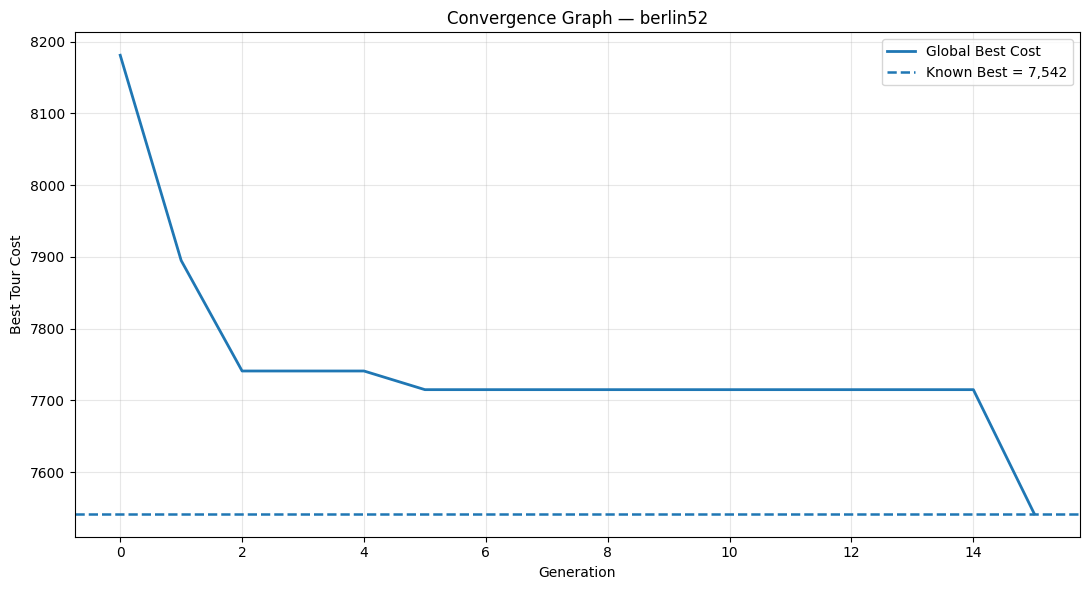

In [22]:
# ============================================================
# BLOCK 20 — GRAPH 1: CONVERGENCE
# ============================================================

def plot_convergence(
    history,
    instance_name,
    optimum=None
):

    generations = range(
        len(history)
    )

    plt.figure(
        figsize=(11, 6)
    )

    plt.plot(
        generations,
        history,
        linewidth=2,
        label="Global Best Cost"
    )


    if optimum is not None:

        plt.axhline(
            y=optimum,
            linestyle="--",
            linewidth=1.8,
            label=f"Known Best = {optimum:,}"
        )


    plt.xlabel(
        "Generation"
    )

    plt.ylabel(
        "Best Tour Cost"
    )

    plt.title(
        f"Convergence Graph — {instance_name}"
    )

    plt.grid(
        True,
        alpha=0.30
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


plot_convergence(
    result["history"],
    instance.name,
    optimum
)

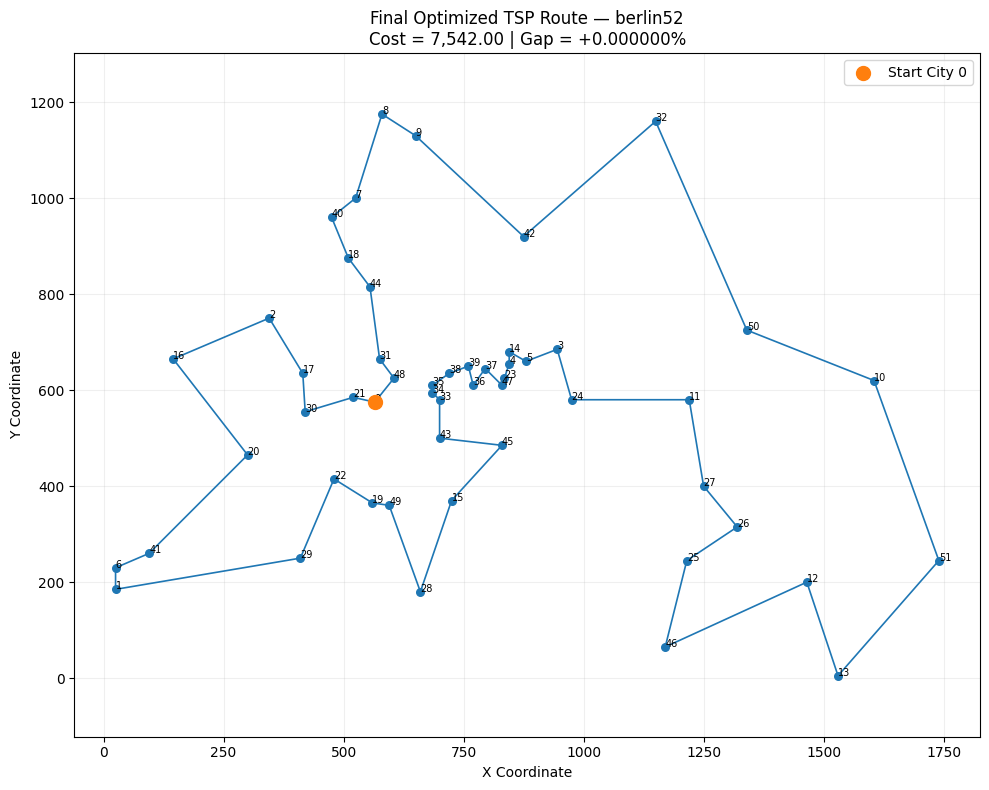

In [23]:
# ============================================================
# BLOCK 21 — GRAPH 2: FINAL OPTIMIZED ROUTE
# ============================================================

def coordinates_for_plot(
    instance
):

    if instance.coords is not None:

        return instance.coords


    # --------------------------------------------------------
    # FALLBACK:
    # Classical MDS embedding from distance matrix
    # --------------------------------------------------------

    d = instance.dist

    n = instance.n

    d2 = d ** 2

    J = (
        np.eye(n)
        -
        np.ones((n, n)) / n
    )

    B = (
        -0.5
        * J
        @ d2
        @ J
    )

    eigenvalues, eigenvectors = (
        np.linalg.eigh(B)
    )

    order = np.argsort(
        eigenvalues
    )[::-1][:2]

    eigenvalues = np.clip(
        eigenvalues[order],
        0,
        None
    )

    return (
        eigenvectors[:, order]
        * np.sqrt(eigenvalues)
    )


def plot_final_route(
    instance,
    tour,
    cost,
    gap
):

    coords = coordinates_for_plot(
        instance
    )


    route = (
        tour
        + [tour[0]]
    )


    x = [
        coords[city, 0]
        for city in route
    ]

    y = [
        coords[city, 1]
        for city in route
    ]


    plt.figure(
        figsize=(10, 8)
    )


    plt.plot(
        x,
        y,
        linewidth=1.2
    )


    plt.scatter(
        coords[:, 0],
        coords[:, 1],
        s=30,
        zorder=3
    )


    # Starting city
    start = tour[0]

    plt.scatter(
        [coords[start, 0]],
        [coords[start, 1]],
        s=100,
        zorder=4,
        label=f"Start City {start}"
    )


    # Label nodes for reasonably sized instances
    if instance.n <= 150:

        for city in range(
            instance.n
        ):

            plt.text(
                coords[city, 0],
                coords[city, 1],
                str(city),
                fontsize=7
            )


    gap_text = (
        f"{gap:+.6f}%"
        if gap is not None
        else "Unknown"
    )


    plt.title(
        f"Final Optimized TSP Route — {instance.name}\n"
        f"Cost = {cost:,.2f} | Gap = {gap_text}"
    )


    plt.xlabel(
        "X Coordinate"
    )

    plt.ylabel(
        "Y Coordinate"
    )

    plt.grid(
        True,
        alpha=0.20
    )

    plt.legend()

    plt.axis(
        "equal"
    )

    plt.tight_layout()

    plt.show()


plot_final_route(
    instance,
    result["best_tour"],
    result["best_cost"],
    final_gap
)